In [7]:
import sys
sys.path.append("/kaggle/input/objects")

from DataClass import *
from Model import *
from modelLossTrain import *
from evaluate import *

torch.Size([256, 256, 3])
torch.Size([256, 256, 3])


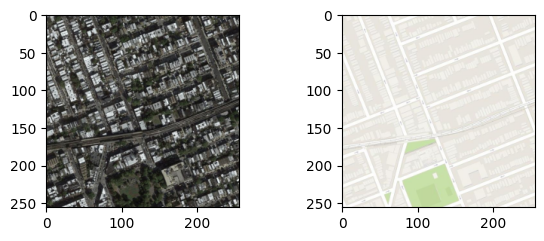

In [8]:
trainData = AerialDataset(r"/kaggle/input/pix2pix-maps/train")
trainLoader = DataLoader(
    trainData,
    batch_size=1,
    shuffle=True
    )

# test
idx = np.random.randint(0,len(trainData))
x,y = trainData[idx]
trainXTest = ((x.permute(1,2,0)+1)/2).clamp(0,1)
print(trainXTest.size())
trainyTest = ((y.permute(1,2,0)+1)/2).clamp(0,1)
print(trainyTest.size())

_,ax = plt.subplots(ncols=2, figsize=(7, 2.5))
ax[0].imshow(trainXTest)
ax[1].imshow(trainyTest)


In [9]:
def trainGAN(trainer, dataloader):
    for epoch in range(50):
        print(f"\nEpoch {epoch+1}/50")

        for i, (realX, realY) in enumerate(dataloader):
            losses = trainer.training(realX, realY)

            if i % 10 == 0:
                print(
                    f"[{i}] "
                    f"D: {losses['loss_D']:.4f} | "
                    f"G: {losses['loss_G']:.4f} | "
                    f"L1: {losses['loss_G_L1']:.4f}"
                )


In [10]:
device = "cuda" if torch.cuda.is_available() else "cpu"
G = GeneratorUnet(3, 3).to(device)
D = discriminatorPatchGAN(6).to(device)
optimizerG = torch.optim.Adam(G.parameters(), lr = 2e-4, betas = (0.5, 0.999))
optimizerD = torch.optim.Adam(D.parameters(), lr = 2e-4, betas = (0.5, 0.999))

trainer = training(
    generator=G,
    discriminator=D,
    optimG=optimizerG,
    optimD=optimizerD,
    device=device
)


In [11]:
trainGAN(trainer, trainLoader)


Epoch 1/50
[0] D: 0.7095 | G: 84.3961 | L1: 0.8353
[10] D: 0.1317 | G: 50.8271 | L1: 0.4779
[20] D: 0.0483 | G: 37.5149 | L1: 0.3388
[30] D: 0.0255 | G: 31.0687 | L1: 0.2641
[40] D: 0.0170 | G: 26.6099 | L1: 0.2199
[50] D: 0.0111 | G: 34.8458 | L1: 0.2918
[60] D: 0.0067 | G: 23.4790 | L1: 0.1787
[70] D: 0.0047 | G: 20.2325 | L1: 0.1448
[80] D: 0.0034 | G: 25.0388 | L1: 0.1903
[90] D: 0.0043 | G: 32.5378 | L1: 0.2650
[100] D: 0.0030 | G: 24.8360 | L1: 0.1854
[110] D: 0.0024 | G: 21.0962 | L1: 0.1470
[120] D: 0.0020 | G: 23.2681 | L1: 0.1686
[130] D: 0.0018 | G: 21.6397 | L1: 0.1509
[140] D: 0.0015 | G: 25.0947 | L1: 0.1813
[150] D: 0.0012 | G: 18.8350 | L1: 0.1170
[160] D: 0.0009 | G: 20.5779 | L1: 0.1325
[170] D: 0.0008 | G: 36.4600 | L1: 0.2924
[180] D: 0.0016 | G: 21.6184 | L1: 0.1488
[190] D: 0.0016 | G: 18.8618 | L1: 0.1193
[200] D: 0.0448 | G: 17.8047 | L1: 0.1370
[210] D: 1.8358 | G: 12.3018 | L1: 0.1174
[220] D: 0.3593 | G: 12.1938 | L1: 0.1043
[230] D: 0.3883 | G: 25.1961 | L1

average l1Loss is 0.07023044024765464
average l2Loss is 0.014994111071917091
average psnr is 25.685324361482404
average ssim is 0.6815466284751892
(3, 256, 256)
(3, 256, 256)
(3, 256, 256)
(3, 256, 256)
(3, 256, 256)


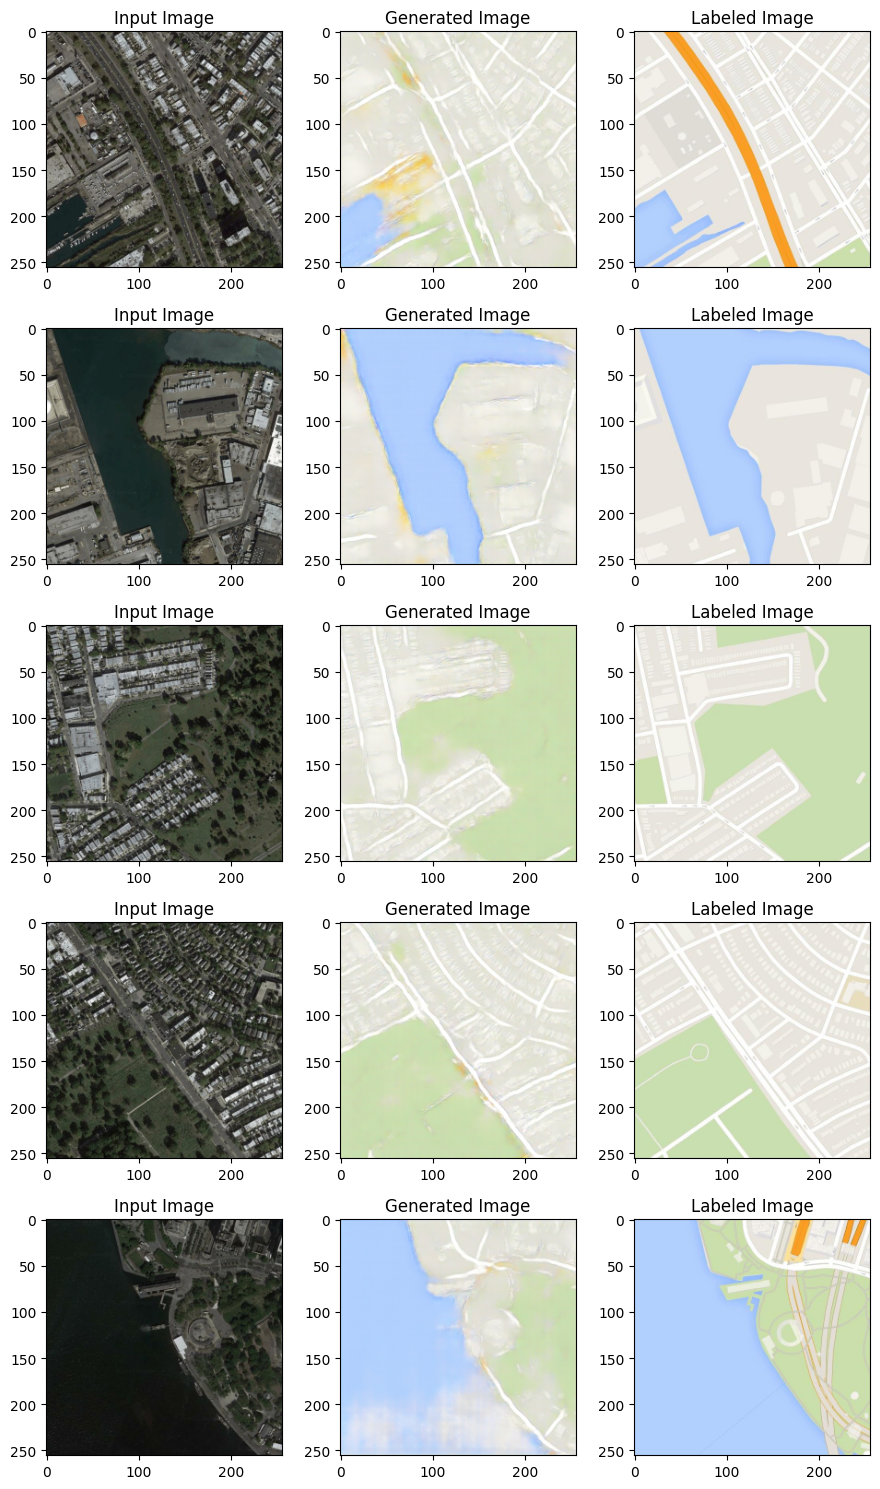

In [12]:
testData = AerialDataset(r"/kaggle/input/pix2pix-maps/val")
testLoader = DataLoader(
    testData,
    batch_size=1,
    shuffle=True
    )
evaluation = evluateModel(G, testLoader, device)
_, _ = evaluation.testEvaluatel1l2()
_, _ = evaluation.testEvaluatePSNR_SSIM()
evaluation.visualize(5)